In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from pathlib import Path
import sys
import os

### Filepaths

In [49]:
### Changing to parent directory
current_file_path = Path("").resolve()
grandparent_dir = current_file_path.parent.parent
# Append this directory to the system path
sys.path.append(str(grandparent_dir))

In [50]:
filepath = os.path.join(grandparent_dir,"ProcessedData/preprocessed_data_final.csv")

### Imported Dataframes

In [51]:
def create_dataframe(filepath, rank, file_num, val_prefix):
    
    '''
    Creates a table of the value for each harmonic integer (1-10) 
    for a given rank and file number (or run number).
    
    Args: 
        filepath (string): filepath to processed data .csv
        file_num (int): file (or run) number
        val_prefix (string): column prefix name to desired value (e.g. "IHr")
    
    Return:
        df_res (pd.DataFrame): resulting dataframe
    
    '''
    
    #Read File
    df = pd.read_csv(filepath)
    df = df[(df["Rank"] == rank) & df["File Number"] == file_num]
    
    #Generate Names of Harmonic Data Columns
    nums = [x for x in range(1,11)]
    cols = [f"{val_prefix}{num}" for num in nums]
    
    #Extract Data from Specific Named Columns
    freq = float(df["Freq"].iloc[0])
    df_res = df[["Modulation"]+cols]
    df_res = df_res.set_index("Modulation").T
    
    #Create Harmonic Number/Frequency Labeling
    df_res = df_res.reset_index().rename(columns={"index": "Harmonic j"})
    df_res["Harmonic j"] = nums
    df_res.insert(1, "Frequency (Hz)", [x*freq for x in nums])
    return df_res
    

In [52]:
df_Vreal = create_dataframe(filepath, 6, 1, "VHr")
df_Vimag = create_dataframe(filepath, 6, 1, "VHi")
df_Ireal = create_dataframe(filepath, 6, 1, "IHr")
df_Iimag = create_dataframe(filepath, 6, 1, "IHi")

In [53]:
df_Iimag

Modulation,Harmonic j,Frequency (Hz),1mV,5mV,10mV,20mV,50mV,100mV
0,1,0.300481,6.334328e-07,3.150815e-06,6.172454e-06,1.175511e-05,2.268082e-05,2.944406e-05
1,2,0.600962,-5.713237e-10,-1.472285e-08,-5.024509e-08,-1.648731e-07,-4.613016e-07,-3.600900e-07
2,3,0.901442,2.558428e-10,-7.426374e-09,-5.881825e-08,-4.285493e-07,-3.770958e-06,-9.737773e-06
3,4,1.201923,-9.356417e-11,1.036877e-09,3.066777e-09,1.396453e-08,1.594794e-07,3.822415e-07
4,5,1.502404,-6.161450e-10,-5.351568e-10,4.058012e-10,1.407107e-08,6.416867e-07,3.926386e-06
5,6,1.802885,-3.727875e-10,-2.178018e-10,-1.601725e-09,-2.888298e-09,-3.964028e-08,-2.243688e-07
6,7,2.103366,1.330084e-11,3.350795e-11,3.735765e-10,-2.741391e-10,-9.865703e-08,-1.502930e-06
7,8,2.403846,2.672498e-10,4.720740e-10,1.916715e-09,2.113695e-09,1.016512e-08,1.103488e-07
8,9,2.704327,-4.140389e-10,-1.613280e-10,-1.773600e-11,-2.824566e-10,1.399531e-08,5.488476e-07
9,10,3.004808,-9.166443e-12,-4.297264e-10,-6.485182e-10,-1.012965e-09,-4.103324e-09,-5.005344e-08


In [54]:
df_Ireal

Modulation,Harmonic j,Frequency (Hz),1mV,5mV,10mV,20mV,50mV,100mV
0,1,0.300481,6.357840e-07,3.164571e-06,6.238577e-06,1.184129e-05,2.232687e-05,2.755177e-05
1,2,0.600962,3.938141e-11,-1.348902e-08,-5.196470e-08,-1.827103e-07,-5.397717e-07,-5.322993e-07
2,3,0.901442,6.683262e-10,-6.702016e-09,-6.442682e-08,-4.839911e-07,-4.186853e-06,-1.052557e-05
3,4,1.201923,-2.904205e-10,-3.881585e-10,4.057669e-10,1.256798e-08,1.810209e-07,4.150401e-07
4,5,1.502404,-8.392466e-10,-1.589596e-09,-1.433799e-09,1.489706e-08,7.548888e-07,4.385873e-06
5,6,1.802885,-2.452074e-10,5.058121e-10,2.103923e-10,-4.092074e-10,-4.525155e-08,-2.518393e-07
6,7,2.103366,2.729253e-10,7.560379e-10,1.786374e-09,1.637116e-09,-1.230772e-07,-1.747994e-06
7,8,2.403846,1.807857e-10,-2.209871e-10,5.274156e-10,1.287556e-10,9.572689e-09,1.289176e-07
8,9,2.704327,-7.737354e-10,-6.516945e-10,-1.444027e-09,-1.896468e-09,1.680603e-08,6.695436e-07
9,10,3.004808,-7.230882e-12,3.483789e-11,6.029059e-10,3.776588e-10,-1.745555e-09,-6.007221e-08


____

### Functions

In [55]:
def scale_series_tail(series, factor, type, conv_flag):
    '''
    Scales the tail end of a series (after index 0) by a given factor
    
    Args: 
        series (pd.Series): input current or voltage series
        factor (int): number that tail end of series will be multiplied by
        type (string): "V" for voltage series and "A" for current series
        conv_flag (boolean): True will convert series to mV or mA, depending on type
    
    Return:
        scaled (pd.Series): modified input series with multiplier applied
    
    '''
    
    conversion = 1
    if conv_flag == True:
        if type == "V":
            conversion = 10**3
        if type == "A":
            conversion = 10**6
        
    if series.empty:
        return series.copy()
    scaled = series.copy() * conversion
    scaled.iloc[1:] = scaled.iloc[1:] * factor
    return scaled

In [56]:
def scale_series_2_ranges(series, start,stop,start2,stop2, factor,factor2, type, conv_flag):
    '''
    Scales two specific ranges of a series by each a given factor
    
    Args: 
        series (pd.Series): input current or voltage series
        start (int): index of series to start first section
        stop (int): index of series to stop first section
        start2 (int): index of series to start second section
        stop2 (int): index of series to stop second section
        factor (int): number that section 1 of series will be multiplied by
        factor2 (int): number that section 2 of series will be multiplied by
        type (string): "V" for voltage series and "A" for current series
        conv_flag (boolean): True will convert series to mV or mA, depending on type
    
    Return:
        scaled (pd.Series): modified input series with the two multipliers applied
    '''
    
    conversion = 1
    if conv_flag == True:
        if type == "V":
            conversion = 10**3
        if type == "A":
            conversion = 10**6
        
    if series.empty:
        return series.copy()
    scaled = series.copy() * conversion
    scaled.iloc[start:stop+1] = scaled.iloc[start:stop+1] * factor
    scaled.iloc[start2:stop2+1] = scaled.iloc[start2:stop2+1] * factor2
    return scaled

In [57]:
def add_bracket(ax, x_start_data, x_end_data, y_top_pct, y_height_pct):
    """
    Draws an upturned or downturned bracket onto a given plot (depending on sign of y_height_pct)
    
    Args:
        ax (matplotlib.axes._axes.Axes): axes of plot to put bracket on
        x_start_data (float): x-value on plot axis to draw left endpoint of bracket
        x_end_data (flaot): x_value on plot axis to draw right endpoint of bracket
        y_top_pct (float): percentage of plot y-axis from bottom edge to draw top of bracket to
        y_height_pct (float): positive (downturned) or negative (upturned) height 
        for bracket legs based on percentage of y-axis total height
    
    Return:
        None
    """
    # Get axis limits for y to compute actual y-coordinates
    y_min, y_max = ax.get_ylim()
    y_top = y_min + y_top_pct * (y_max - y_min)
    y_bottom = y_top - y_height_pct * (y_max - y_min)

    # Draw horizontal line
    ax.plot([x_start_data, x_end_data], [y_top, y_top], color='black', linewidth=1)

    # Draw vertical ends
    ax.plot([x_start_data, x_start_data], [y_top, y_bottom], color='black', linewidth=1)
    ax.plot([x_end_data, x_end_data], [y_top, y_bottom], color='black', linewidth=1)

____

# 1. Voltage Shifted

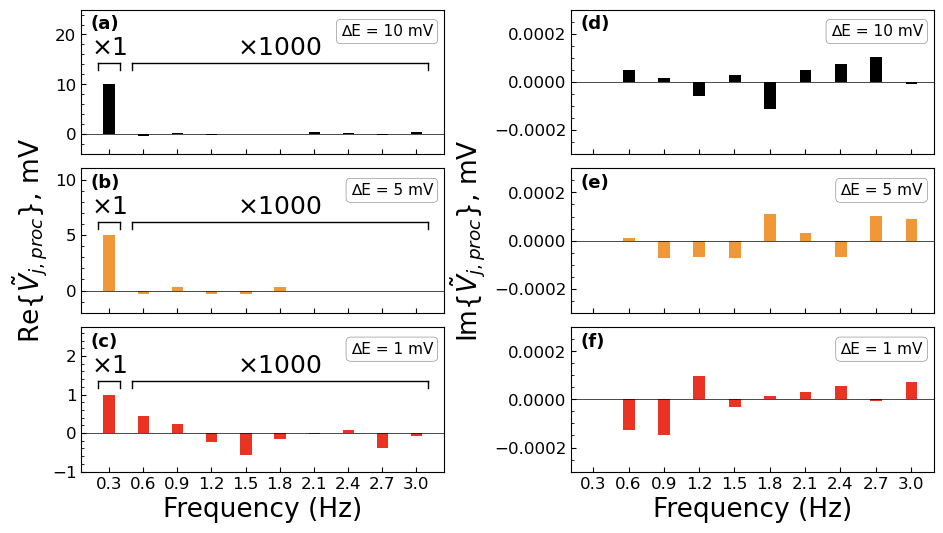

In [58]:
#Create Figure
fig, axs = plt.subplots(3, 2, sharex='col', figsize=(11, 6))
fig.subplots_adjust(hspace=0.1, wspace=0.35)

#Plot Variables
fontsize=19
label_fontsize = 13
legend_fontsize = 11
mult_fontsize = 18
bar_width = 0.1
frequencies = df_Vreal['Frequency (Hz)']
colors = [(234, 51, 35), (240, 152, 55), (0, 0, 0)]
colors = [tuple(c / 255 for c in color) for color in colors]
labels = ["∆E = 10 mV", "∆E = 5 mV", "∆E = 1 mV"]
cols = ["10mV", "5mV", "1mV"]
subplot_labels = ['(a)', '(d)', '(b)', '(e)', '(c)', '(f)']
y_lims_min = [-4, -2, -1]
y_lims_max = [25, 11, 2.75]
gray_rgb = (122/255, 122/255, 122/255)
mult_reals = [1000,1000,1000]
mult_imags = [1000,1000,1000]

count = 0
for i in range(3):
    # LEFT: Real Voltage
    axs[i, 0].bar(frequencies, scale_series_tail(df_Vreal[cols[i]], mult_reals[i], "V", True),
                  width=bar_width, color=colors[2 - i])
    if i == 1:
        axs[i, 0].set_ylabel(r'Re{$\tilde{V}_{j,proc}$}, mV', fontsize=fontsize)
    axs[i, 0].set_ylim(y_lims_min[i], y_lims_max[i])

    # RIGHT: Imaginary Voltage
    axs[i, 1].bar(frequencies, df_Vimag[cols[i]] * 1e3,  # mV
                  width=bar_width, color=colors[2 - i])
    if i == 1:
        axs[i, 1].set_ylabel(r'Im{$\tilde{V}_{j,proc}$}, mV', fontsize=fontsize)
    axs[i, 1].set_ylim(-0.0003, 0.0003)  # in mV

    #Format Axes / Tick Marks / Add Brackets
    for j in [0, 1]:
        ax = axs[i, j]
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax.minorticks_on()
        ax.tick_params(axis='x', which='minor', bottom=False, top=False)
        ax.tick_params(which='both', direction='in', labelsize=12)
        ax.text(0.025, 0.965, subplot_labels[count], transform=ax.transAxes,
            fontsize=label_fontsize, fontweight='bold', va='top', ha='left')

        # Create Custom Legend Textbox
        ax.text(0.97, 0.9, labels[i],
                transform=ax.transAxes,
                fontsize=legend_fontsize,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round',
                          facecolor='white',
                          edgecolor=gray_rgb,
                          linewidth=0.4))

        # Brackets under x-axis (only on Real side)
        if j == 0:
            overhang = 0.05
            x1_start, x1_end = 0.15 + overhang, 0.45 - overhang
            x2_start, x2_end = 0.45 + overhang, 3.15 - overhang
            x1_mid = (x1_start + x1_end) / 2
            x2_mid = (x2_start + x2_end) / 2
            add_bracket(ax, x1_start, x1_end, 0.63, 0.05)
            add_bracket(ax, x2_start, x2_end, 0.63, 0.05)
            ax.text(x1_mid, 0.82, r'$\times 1$', transform=ax.get_xaxis_transform(),
                    fontsize=mult_fontsize, verticalalignment='top', horizontalalignment='center')
            ax.text(x2_mid, 0.82, rf'$\times {mult_reals[i]}$', transform=ax.get_xaxis_transform(),
                    fontsize=mult_fontsize, verticalalignment='top', horizontalalignment='center')
        
        count += 1
        
# X-axis label and ticks (bottom row only)
for j in [0, 1]:
    axs[2, j].set_xlabel('Frequency (Hz)', fontsize=fontsize)
    axs[2, j].set_xticks([0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3.0])

#Show/Save Figure
plt.savefig("Processed_Voltage_Signal_Analysis.png", dpi=500, bbox_inches='tight', pad_inches=0.1)
plt.show()


# 2. Current Shifted

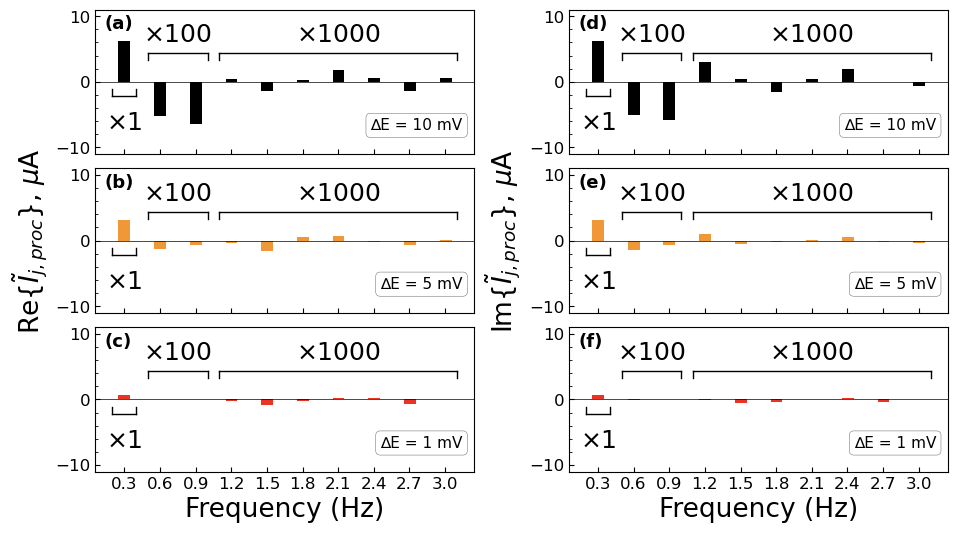

In [59]:
#Create Figure
fig, axs = plt.subplots(3, 2, sharex='col', figsize=(11, 6))
fig.subplots_adjust(hspace=0.1, wspace=0.25)

#Plot Variables
fontsize=19
label_fontsize = 13
legend_fontsize = 11
mult_fontsize = 18
bar_width = 0.1
frequencies = df_Vreal['Frequency (Hz)']
colors = [(234, 51, 35), (240, 152, 55), (0, 0, 0)]
colors = [tuple(c / 255 for c in color) for color in colors]
labels = ["∆E = 10 mV", "∆E = 5 mV", "∆E = 1 mV"]
cols = ["10mV","5mV","1mV"]
subplot_labels = ['(a)', '(d)', '(b)', '(e)', '(c)', '(f)']
mult = 100
mult2 = 1000
gray_rgb = (122 / 255, 122 / 255, 122 / 255)
count = 0

for i in range(3):
    # LEFT: Real Current
    axs[i, 0].bar(frequencies, scale_series_2_ranges(df_Ireal[cols[i]], 1, 2, 3,
                len(df_Ireal[cols[i]]) - 1, mult, mult2, "A", True),
                width=bar_width, color=colors[2 - i])
    if i ==1:
        axs[i, 0].set_ylabel(r'Re{$\tilde{I}_{j,proc}$}, $\mu$A', fontsize=fontsize)
    axs[i, 0].set_ylim(-11, 11)

    # RIGHT: Imaginary Current
    axs[i, 1].bar(frequencies, scale_series_2_ranges(df_Iimag[cols[i]], 1, 2, 3,
                len(df_Iimag[cols[i]]) - 1, mult, mult2, "A", True),
                width=bar_width, color=colors[2 - i])
    axs[i, 1].set_ylim(-11, 11)
    if i ==1:
        axs[i, 1].set_ylabel(r'Im{$\tilde{I}_{j,proc}$}, $\mu$A', fontsize=fontsize)

    #Format Axes / Tick Marks / Add Brackets 
    for j in [0, 1]:
        ax = axs[i, j]
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax.minorticks_on()
        ax.tick_params(axis='x', which='minor', bottom=False, top=False)
        ax.tick_params(which='both', direction='in', labelsize=12)
        ax.text(0.025, 0.965, subplot_labels[count], transform=ax.transAxes,
                fontsize=label_fontsize, fontweight='bold', va='top', ha='left')

        # Custom Legend Textbox
        ax.text(0.97, 0.25, labels[i],
                transform=ax.transAxes,
                fontsize=legend_fontsize,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round',
                          facecolor='white',
                          edgecolor=gray_rgb,
                          linewidth=0.4))

        # Brackets and scaling
        overhang = 0.05
        x1_start, x1_end = 0.15 + overhang, 0.45 - overhang
        x2_start, x2_end = 0.45 + overhang, 1.05 - overhang
        x3_start, x3_end = 1.05 + overhang, 3.15 - overhang
        x1_mid = (x1_start + x1_end) / 2
        x2_mid = (x2_start + x2_end) / 2
        x3_mid = (x3_start + x3_end) / 2
        add_bracket(ax, x1_start, x1_end, 0.4, -0.05)
        add_bracket(ax, x2_start, x2_end, 0.7, 0.05)
        add_bracket(ax, x3_start, x3_end, 0.7, 0.05)
        ax.text(x1_mid, 0.3, r'$\times 1$', transform=ax.get_xaxis_transform(),
                fontsize=mult_fontsize, verticalalignment='top', horizontalalignment='center')
        ax.text(x2_mid, 0.91, rf'$\times {mult}$', transform=ax.get_xaxis_transform(),
                fontsize=mult_fontsize, verticalalignment='top', horizontalalignment='center')
        ax.text(x3_mid, 0.91, rf'$\times {mult2}$', transform=ax.get_xaxis_transform(),
                fontsize=mult_fontsize, verticalalignment='top', horizontalalignment='center')
        
        count += 1

# X-axis label and ticks for bottom row
axs[2, 0].set_xlabel('Frequency (Hz)', fontsize=fontsize)
axs[2, 1].set_xlabel('Frequency (Hz)', fontsize=fontsize)
xticks = [0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3.0]
axs[2, 0].set_xticks(xticks)
axs[2, 1].set_xticks(xticks)

#Show/Save Figure
plt.savefig("Figure2_Processed_Current_Signal_Analysis.png", dpi=500, bbox_inches='tight', pad_inches=0.1)
plt.show()
